In [21]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import layers,models,regularizers
import numpy as np
import matplotlib.pyplot as plt

In [22]:
(train_x,train_y),(test_x,test_y) = mnist.load_data()

In [23]:
print("train_x.shape : ",train_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (60000, 28, 28)
test_x.shape :  (10000, 28, 28)


In [24]:
train_x = train_x.reshape((train_x.shape[0],28*28)).astype('float32') / 255
test_x = test_x.reshape((10000,28*28)).astype('float32') / 255

# train_x = train_x.astype('float32') / 255
# test_x = test_x.astype('float32') / 255

train_y = to_categorical(train_y)
test_y = to_categorical(test_y)

In [25]:
validation_x = train_x[50000:60000]
validation_y = train_y[50000:60000]

train_x = train_x[:50000]
train_y = train_y[:50000]

print("train_x.shape : ",train_x.shape)
print("validation_x.shape : ",validation_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (50000, 784)
validation_x.shape :  (10000, 784)
test_x.shape :  (10000, 784)


In [26]:
def buildModel(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dense(neuronNum , activation='relu') ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [27]:
def buildModelRegulalize(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , kernel_regularizer=regularizers.l2(0.001) , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dense(neuronNum , kernel_regularizer=regularizers.l2(0.001) , activation='relu') ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [28]:
def buildModelDropout(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dropout(0.5) ,
        layers.Dense(neuronNum , activation='relu') ,
        layers.Dropout(0.5) ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [29]:
history_smaller = buildModel(32, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - accuracy: 0.8420 - loss: 0.6042 - val_accuracy: 0.9173 - val_loss: 0.2898
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step - accuracy: 0.9233 - loss: 0.2656 - val_accuracy: 0.9319 - val_loss: 0.2330
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - accuracy: 0.9381 - loss: 0.2121 - val_accuracy: 0.9471 - val_loss: 0.1872
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - accuracy: 0.9475 - loss: 0.1825 - val_accuracy: 0.9516 - val_loss: 0.1685
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.9533 - loss: 0.1628 - val_accuracy: 0.9558 - val_loss: 0.1580
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.9573 - loss: 0.1470 - val_accuracy: 0.9563 - val_loss: 0.1537
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - accuracy: 0.9610 - loss: 0.1348 - val_accuracy: 0.9530 - val_loss: 0.1626
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - accuracy: 0.9638 - loss: 0.1248 - 

In [30]:
history_original = buildModel(64, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8653 - loss: 0.4898 - val_accuracy: 0.9261 - val_loss: 0.2629
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - accuracy: 0.9348 - loss: 0.2225 - val_accuracy: 0.9338 - val_loss: 0.2310
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - accuracy: 0.9503 - loss: 0.1715 - val_accuracy: 0.9521 - val_loss: 0.1686
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - accuracy: 0.9580 - loss: 0.1414 - val_accuracy: 0.9633 - val_loss: 0.1339
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - accuracy: 0.9646 - loss: 0.1203 - val_accuracy: 0.9608 - val_loss: 0.1395
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - accuracy: 0.9689 - loss: 0.1046 - val_accuracy: 0.9638 - val_loss: 0.1302
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - accuracy: 0.9724 - loss: 0.0918 - val_accuracy: 0.9683 - val_loss: 0.1123
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - accuracy: 0.9755 - loss: 0.0809 - va

In [31]:
history_larger = buildModel(512, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9014 - loss: 0.3233 - val_accuracy: 0.9566 - val_loss: 0.1475
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9641 - loss: 0.1141 - val_accuracy: 0.9590 - val_loss: 0.1302
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9773 - loss: 0.0713 - val_accuracy: 0.9695 - val_loss: 0.1030
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9848 - loss: 0.0497 - val_accuracy: 0.9751 - val_loss: 0.0876
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9889 - loss: 0.0352 - val_accuracy: 0.9731 - val_loss: 0.0935
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0257 - val_accuracy: 0.9756 - val_loss: 0.0884
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9943 - loss: 0.0179 - val_accuracy: 0.9770 - val_loss: 0.0886
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9960 - loss: 0.0129 - val_accuracy: 0.

In [32]:
def plotLoss(history,name) :
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs,loss,'r',label='Training loss')
    plt.plot(epochs,val_loss,'b',label='Validation loss')
    plt.title('Training and Validation Loss '+ name)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [33]:
def plotAcc(history,name) :
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1 , len(accuracy) + 1)
    plt.plot(epochs,accuracy,'r',label='Training Accuracy')
    plt.plot(epochs,val_accuracy,'b',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy ' + name)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

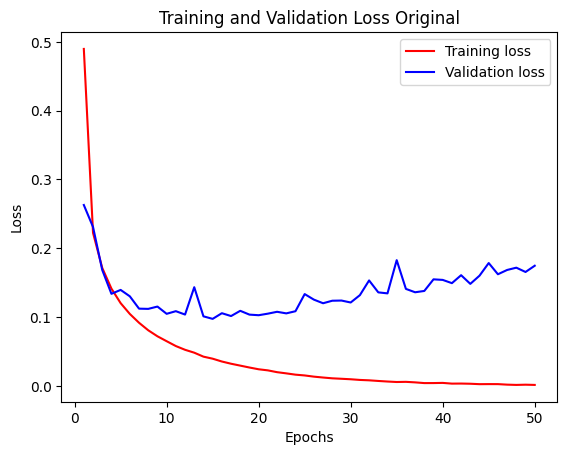

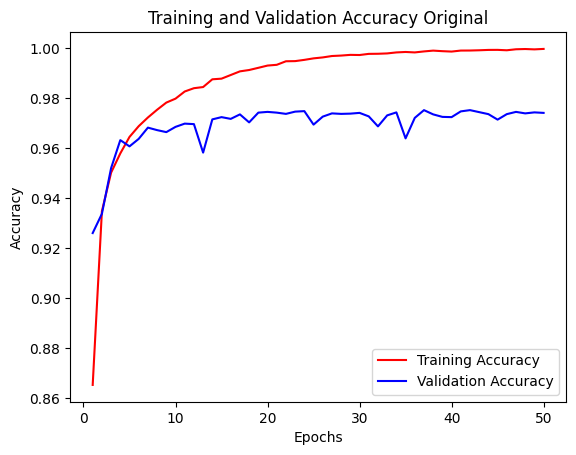

In [34]:
plotLoss(history_original,"Original")
plotAcc(history_original,"Original")

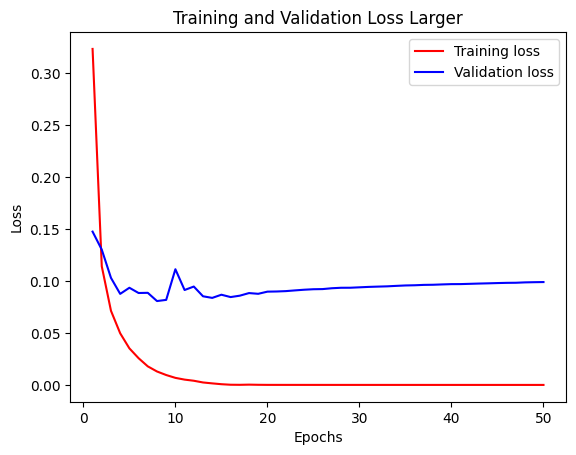

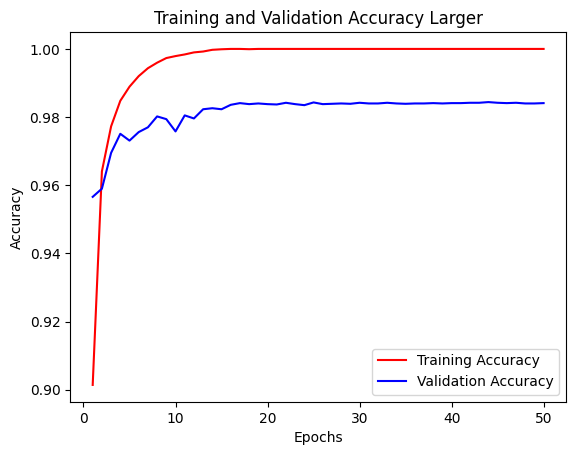

In [35]:
plotLoss(history_larger,"Larger")
plotAcc(history_larger,"Larger")

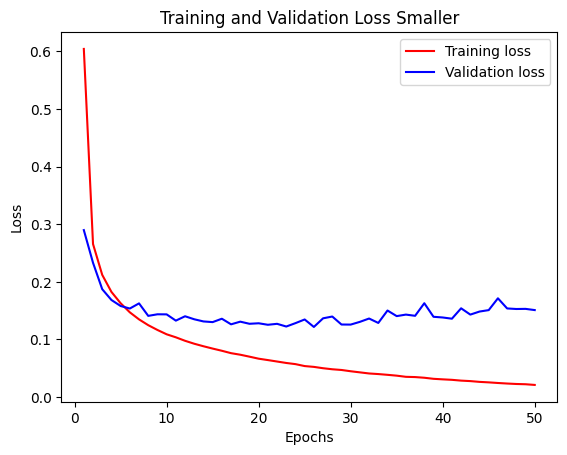

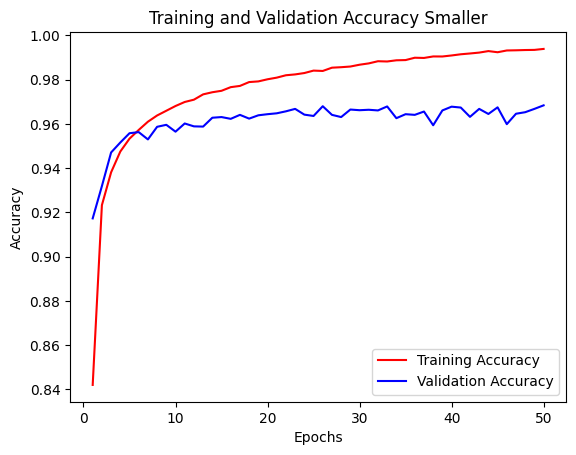

In [36]:
plotLoss(history_smaller,"Smaller")
plotAcc(history_smaller,"Smaller")

In [37]:
history_Dropout = buildModelDropout(64 , train_x).fit(train_x,train_y,epochs=50,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6272 - loss: 1.1360 - val_accuracy: 0.9072 - val_loss: 0.3389
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.8255 - loss: 0.5896 - val_accuracy: 0.9299 - val_loss: 0.2502
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.8605 - loss: 0.4835 - val_accuracy: 0.9344 - val_loss: 0.2305
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - accuracy: 0.8769 - loss: 0.4373 - val_accuracy: 0.9403 - val_loss: 0.2053
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - accuracy: 0.8872 - loss: 0.3985 - val_accuracy: 0.9457 - val_loss: 0.1917
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.8940 - loss: 0.3769 - val_accuracy: 0.9485 - val_loss: 0.1878
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.8985 - loss: 0.3561 - val_accuracy: 0.9524 - val_loss: 0.1743
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - accuracy: 0.9014 - loss: 0.3461 - va

In [38]:
history_Regularized = buildModelRegulalize(64 , train_x).fit(train_x,train_y,epochs=50,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8556 - loss: 0.6809 - val_accuracy: 0.9130 - val_loss: 0.4296
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step - accuracy: 0.9261 - loss: 0.3885 - val_accuracy: 0.9292 - val_loss: 0.3608
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - accuracy: 0.9399 - loss: 0.3295 - val_accuracy: 0.9312 - val_loss: 0.3500
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - accuracy: 0.9487 - loss: 0.2910 - val_accuracy: 0.9491 - val_loss: 0.2846
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.9552 - loss: 0.2627 - val_accuracy: 0.9550 - val_loss: 0.2582
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - accuracy: 0.9600 - loss: 0.2418 - val_accuracy: 0.9610 - val_loss: 0.2337
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step - accuracy: 0.9634 - loss: 0.2269 - val_accuracy: 0.9641 - val_loss: 0.2270
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - accuracy: 0.9669 - loss: 0.2135 - va

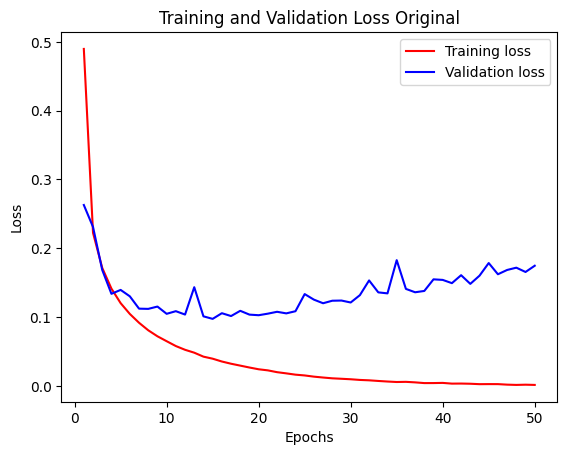

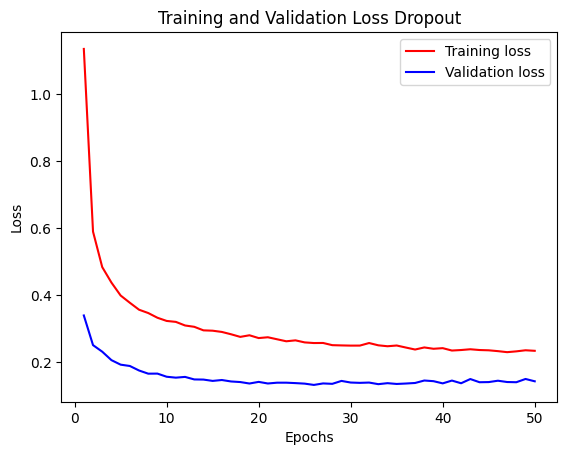

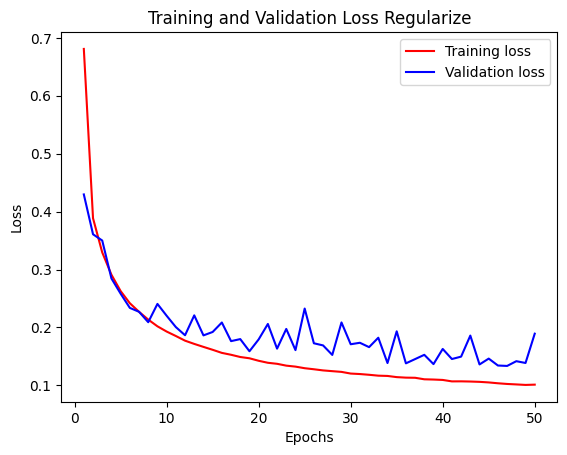

In [39]:
plotLoss(history_original,'Original')
plotLoss(history_Dropout,'Dropout')
plotLoss(history_Regularized,'Regularize')

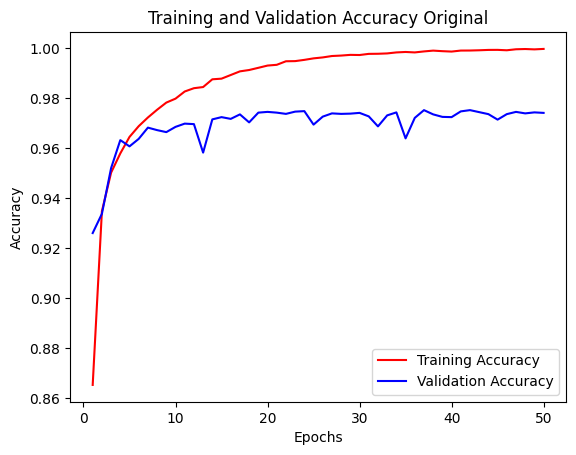

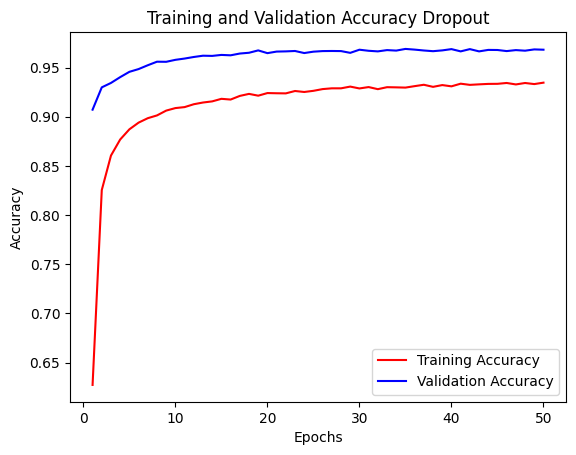

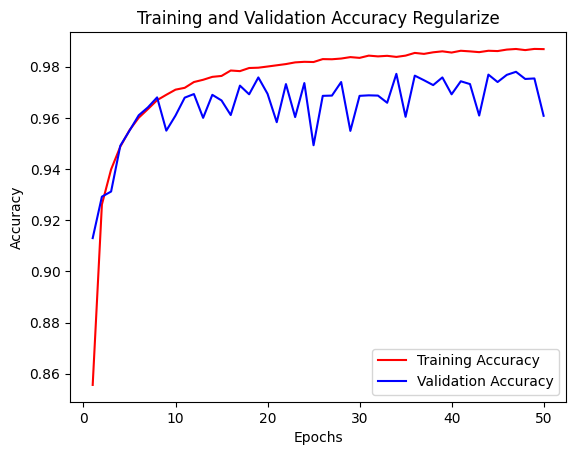

In [40]:
plotAcc(history_original,'Original')
plotAcc(history_Dropout,'Dropout')
plotAcc(history_Regularized,'Regularize')